In [1]:
# Cell 1: Imports and GPU Setup

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import time
import gc
from sklearn.model_selection import train_test_split
import nibabel as nib

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

print("="*70)
print("DENSE CONTRASTIVE LEARNING - ViT FOR SEGMENTATION")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("="*70)

DENSE CONTRASTIVE LEARNING - ViT FOR SEGMENTATION
PyTorch version: 2.6.0+cu124
CUDA available: True
Device: cuda
GPU: Tesla T4
GPU Memory: 15.83 GB


In [2]:
# Cell 2: Configuration for Dense Contrastive Learning

class Config:
    # Paths
    TRAIN_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData'
    VAL_PATH = '/kaggle/input/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_ValidationData'
    
    # Image parameters
    IMG_SIZE = 128
    CHANNELS = 4
    NUM_CLASSES = 4
    SLICE_RANGE = (40, 120)
    
    # Architecture
    PATCH_SIZE = 16
    NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 64
    EMBED_DIM = 768
    NUM_LAYERS = 12
    NUM_HEADS = 12
    MLP_RATIO = 4.0
    
    # Dense Contrastive Learning parameters
    DENSECL_BATCH_SIZE = 32
    DENSECL_EPOCHS = 100
    DENSECL_LEARNING_RATE = 1e-4
    DENSECL_WEIGHT_DECAY = 0.05
    DENSECL_WARMUP_EPOCHS = 10
    DENSECL_TEMPERATURE = 0.07
    
    # WEAK augmentation (preserves spatial structure)
    DENSECL_FLIP_PROB = 0.5
    DENSECL_ROTATION_PROB = 0.5
    DENSECL_COLOR_JITTER = 0.15  # Weaker than SimCLR (0.4)
    DENSECL_BLUR_PROB = 0.3
    DENSECL_NOISE_PROB = 0.2
    
    # Fine-tuning parameters
    FT_BATCH_SIZE = 8
    FT_EPOCHS = 50
    FT_LEARNING_RATE_ENCODER = 5e-7
    FT_LEARNING_RATE_DECODER = 1e-4
    FT_WEIGHT_DECAY = 0.01
    FT_DROPOUT = 0.2
    FT_LABEL_SMOOTHING = 0.1
    FT_FREEZE_EPOCHS = 30
    FT_PATIENCE = 15
    
    # Data split
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    
    # Optimization
    MIXED_PRECISION = True
    GRADIENT_CLIP = 1.0
    
    # Seeds
    SEED = 42

config = Config()

# Set seeds
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(config.SEED)
    torch.cuda.manual_seed_all(config.SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("="*70)
print("DENSE CONTRASTIVE LEARNING CONFIGURATION")
print("="*70)
print(f"Method: Pixel-Level Contrastive Learning (DenseCL)")
print(f"Key Difference from SimCLR: Matches patches at SAME positions")
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Patches: {config.NUM_PATCHES} (8x8 grid)")
print(f"Temperature: {config.DENSECL_TEMPERATURE}")
print(f"Augmentation: WEAK (preserves spatial structure)")
print(f"DenseCL Epochs: {config.DENSECL_EPOCHS}")
print(f"Fine-tuning Epochs: {config.FT_EPOCHS}")
print("="*70)

DENSE CONTRASTIVE LEARNING CONFIGURATION
Method: Pixel-Level Contrastive Learning (DenseCL)
Key Difference from SimCLR: Matches patches at SAME positions
Image Size: 128x128
Patches: 64 (8x8 grid)
Temperature: 0.07
Augmentation: WEAK (preserves spatial structure)
DenseCL Epochs: 100
Fine-tuning Epochs: 50


In [3]:
# Cell 3: Data Loading Functions

def load_nifti(filepath):
    img = nib.load(filepath)
    data = img.get_fdata()
    del img
    return data

def load_patient_data(patient_dir):
    patient_id = os.path.basename(patient_dir)
    
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    del t1, t1ce, t2, flair
    
    try:
        mask = load_nifti(os.path.join(patient_dir, f'{patient_id}_seg.nii'))
    except:
        mask = None
    
    return image, mask, patient_id

def get_patient_list(data_path):
    return sorted([os.path.join(data_path, d) for d in os.listdir(data_path) 
                   if os.path.isdir(os.path.join(data_path, d))])

def remap_mask(mask):
    if mask is None:
        return None
    mask_copy = mask.copy()
    mask_copy[mask == 4] = 3
    mask_copy = np.clip(mask_copy, 0, 3)
    return mask_copy

def normalize_image(image):
    normalized = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[-1]):
        modality = image[..., i]
        mean = np.mean(modality)
        std = np.std(modality)
        if std > 0:
            normalized[..., i] = (modality - mean) / std
        else:
            normalized[..., i] = modality - mean
    return normalized

def extract_slices_from_patient(image, mask, slice_range, img_size):
    slices_x = []
    slices_y = []
    
    for z in range(slice_range[0], slice_range[1]):
        img_slice = image[:, :, z, :]
        
        if mask is not None:
            mask_slice = mask[:, :, z]
            if np.sum(mask_slice) < 100:
                continue
        else:
            if np.sum(img_slice) < 1000:
                continue
        
        img_resized = cv2.resize(img_slice, (img_size, img_size))
        img_normalized = normalize_image(img_resized)
        slices_x.append(img_normalized)
        
        if mask is not None:
            mask_slice = mask[:, :, z]
            mask_resized = cv2.resize(mask_slice, (img_size, img_size), 
                                     interpolation=cv2.INTER_NEAREST)
            mask_remapped = remap_mask(mask_resized)
            slices_y.append(mask_remapped)
    
    return np.array(slices_x, dtype=np.float32), \
           np.array(slices_y, dtype=np.uint8) if slices_y else None

def process_patients(patient_paths, slice_range, img_size):
    all_images = []
    all_masks = []
    
    for patient_dir in tqdm(patient_paths, desc="Processing patients"):
        try:
            image, mask, patient_id = load_patient_data(patient_dir)
            slices_x, slices_y = extract_slices_from_patient(
                image, mask, slice_range, img_size
            )
            
            if len(slices_x) > 0:
                all_images.append(slices_x)
                if slices_y is not None:
                    all_masks.append(slices_y)
            
            del image, mask, slices_x, slices_y
            
        except Exception as e:
            print(f"Error processing {patient_dir}: {e}")
    
    X = np.concatenate(all_images, axis=0)
    y = np.concatenate(all_masks, axis=0) if all_masks else None
    
    del all_images, all_masks
    
    return X, y

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


In [4]:
# Cell 4: Split and Process Data

print("="*70)
print("DATA PREPARATION")
print("="*70)

# Get patient lists
labeled_patients = get_patient_list(config.TRAIN_PATH)
print(f"Total labeled patients: {len(labeled_patients)}")

# Split
train_patients, temp_patients = train_test_split(
    labeled_patients, 
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=config.TEST_SPLIT / (config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED
)

unlabeled_patients = get_patient_list(config.VAL_PATH)
densecl_patients = train_patients + unlabeled_patients

print(f"Train: {len(train_patients)} patients")
print(f"Val: {len(val_patients)} patients")
print(f"Test: {len(test_patients)} patients")
print(f"DenseCL: {len(densecl_patients)} patients")

# Process data
print("\nProcessing DenseCL data...")
X_densecl, _ = process_patients(densecl_patients, config.SLICE_RANGE, config.IMG_SIZE)

print("\nProcessing training data...")
X_train, y_train = process_patients(train_patients, config.SLICE_RANGE, config.IMG_SIZE)

print("\nProcessing validation data...")
X_val, y_val = process_patients(val_patients, config.SLICE_RANGE, config.IMG_SIZE)

print("\nProcessing test data...")
X_test, y_test = process_patients(test_patients, config.SLICE_RANGE, config.IMG_SIZE)

print("\n" + "="*70)
print("FINAL DATA SHAPES")
print("="*70)
print(f"DenseCL: {X_densecl.shape}")
print(f"Train:   {X_train.shape}, {y_train.shape}")
print(f"Val:     {X_val.shape}, {y_val.shape}")
print(f"Test:    {X_test.shape}, {y_test.shape}")
print(f"Mask values: {np.unique(y_train)}")
print("="*70)

DATA PREPARATION
Total labeled patients: 369
Train: 258 patients
Val: 55 patients
Test: 56 patients
DenseCL: 383 patients

Processing DenseCL data...


Processing patients: 100%|██████████| 383/383 [08:35<00:00,  1.35s/it]



Processing training data...


Processing patients: 100%|██████████| 258/258 [05:53<00:00,  1.37s/it]



Processing validation data...


Processing patients: 100%|██████████| 55/55 [01:39<00:00,  1.80s/it]



Processing test data...


Processing patients: 100%|██████████| 56/56 [01:39<00:00,  1.77s/it]



FINAL DATA SHAPES
DenseCL: (24212, 128, 128, 4)
Train:   (14229, 128, 128, 4), (14229, 128, 128)
Val:     (2998, 128, 128, 4), (2998, 128, 128)
Test:    (3000, 128, 128, 4), (3000, 128, 128)
Mask values: [0 1 2 3]


In [5]:
# Cell 5: DenseCL Dataset with WEAK Augmentation

class DenseContrastiveAugmentation:
    """WEAK augmentation that preserves spatial structure"""
    def __init__(self, config):
        self.config = config
    
    def __call__(self, image):
        """Apply weak augmentation"""
        # image: (H, W, C)
        
        # 1. Horizontal flip (50%)
        if np.random.rand() > 0.5:
            image = np.fliplr(image)
        
        # 2. Vertical flip (50%)
        if np.random.rand() > 0.5:
            image = np.flipud(image)
        
        # 3. Rotation by 90-degree increments ONLY (preserves grid structure)
        if np.random.rand() < self.config.DENSECL_ROTATION_PROB:
            k = np.random.choice([1, 2, 3])  # 90, 180, 270
            image = np.rot90(image, k, axes=(0, 1))
        
        # 4. WEAK color jitter per channel
        if np.random.rand() < 0.5:
            for c in range(image.shape[-1]):
                # Brightness
                beta = np.random.uniform(-self.config.DENSECL_COLOR_JITTER, 
                                        self.config.DENSECL_COLOR_JITTER)
                image[:, :, c] = image[:, :, c] + beta
                
                # Contrast
                alpha = np.random.uniform(1 - self.config.DENSECL_COLOR_JITTER, 
                                         1 + self.config.DENSECL_COLOR_JITTER)
                mean = np.mean(image[:, :, c])
                image[:, :, c] = alpha * (image[:, :, c] - mean) + mean
        
        # 5. WEAK Gaussian noise
        if np.random.rand() < self.config.DENSECL_NOISE_PROB:
            noise = np.random.normal(0, 0.03, image.shape)  # Less noise than SimCLR
            image = image + noise
        
        # 6. WEAK Gaussian blur
        if np.random.rand() < self.config.DENSECL_BLUR_PROB:
            from scipy.ndimage import gaussian_filter
            sigma = np.random.uniform(0.5, 1.0)  # Less blur than SimCLR
            for c in range(image.shape[-1]):
                image[:, :, c] = gaussian_filter(image[:, :, c], sigma=sigma)
        
        # Clip values
        image = np.clip(image, -3, 3)
        
        return image


class DenseCLDataset(Dataset):
    """Dataset for Dense Contrastive Learning"""
    def __init__(self, images, config):
        self.images = images
        self.config = config
        self.augmentation = DenseContrastiveAugmentation(config)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx].copy()
        
        # Generate two augmented views
        # CRITICAL: Use SAME transformation for both views to preserve correspondence
        # But with different random parameters
        view1 = self.augmentation(image.copy())
        view2 = self.augmentation(image.copy())
        
        # Convert to tensor
        view1 = torch.from_numpy(view1.copy()).float().permute(2, 0, 1)
        view2 = torch.from_numpy(view2.copy()).float().permute(2, 0, 1)
        
        return view1, view2

# Create dataset
densecl_dataset = DenseCLDataset(X_densecl, config)
densecl_loader = DataLoader(
    densecl_dataset,
    batch_size=config.DENSECL_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"✅ DenseCL dataset created!")
print(f"   Total samples: {len(densecl_dataset)}")
print(f"   Batches: {len(densecl_loader)}")
print(f"   Augmentation: WEAK (preserves spatial structure)")

✅ DenseCL dataset created!
   Total samples: 24212
   Batches: 757
   Augmentation: WEAK (preserves spatial structure)


In [6]:
# Cell 6: Architecture Components

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=4, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, 
                             kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        x = self.proj(x)  # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, N, D)
        return x


class ViTEncoder(nn.Module):
    """ViT Encoder that outputs patch-level features"""
    def __init__(self, num_patches=64, embed_dim=768, num_layers=12, 
                 num_heads=12, mlp_ratio=4.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_patches = num_patches
        
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                dropout=0.0,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
    def forward(self, x):
        """
        Args:
            x: (B, N, D)
        Returns:
            (B, N, D) - patch-level features (NOT global!)
        """
        x = x + self.pos_embed
        
        for block in self.blocks:
            x = block(x)
        
        return self.norm(x)

print("✅ Architecture components defined!")

✅ Architecture components defined!


In [7]:
# Cell 7: Dense Contrastive Loss

class DenseContrastiveLoss(nn.Module):
    """
    Dense Contrastive Loss - matches patches at SAME spatial positions
    
    Key difference from SimCLR:
    - SimCLR: Matches global embeddings (ignores spatial info)
    - DenseCL: Matches patch embeddings at same position (preserves spatial info)
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, features_1, features_2):
        """
        Args:
            features_1: (B, N, D) - patch features from view 1
            features_2: (B, N, D) - patch features from view 2
        
        Returns:
            loss: scalar
        """
        batch_size, num_patches, embed_dim = features_1.shape
        
        # Normalize features
        features_1 = F.normalize(features_1, dim=-1)  # (B, N, D)
        features_2 = F.normalize(features_2, dim=-1)  # (B, N, D)
        
        # Reshape: (B*N, D)
        f1_flat = features_1.reshape(-1, embed_dim)
        f2_flat = features_2.reshape(-1, embed_dim)
        
        # Compute similarity matrix: (B*N, B*N)
        sim_matrix = torch.mm(f1_flat, f2_flat.t()) / self.temperature
        
        # Create labels
        # Positive pairs: patches at SAME position in different views
        # For patch i in batch b: positive is patch i in batch b from other view
        labels = torch.arange(batch_size * num_patches, device=features_1.device)
        
        # Mask self-similarity
        mask = torch.eye(batch_size * num_patches, dtype=torch.bool, device=features_1.device)
        
        # Use safe value for FP16
        if sim_matrix.dtype == torch.float16:
            sim_matrix = sim_matrix.masked_fill(mask, -65000.0)
        else:
            sim_matrix = sim_matrix.masked_fill(mask, -1e9)
        
        # Compute loss
        loss = self.criterion(sim_matrix, labels)
        
        return loss


print("="*70)
print("DENSE CONTRASTIVE LOSS EXPLAINED")
print("="*70)
print("SimCLR Loss:")
print("  - Matches: Global image embeddings (CLS token)")
print("  - Goal: Images should be similar regardless of spatial changes")
print("  - Problem: Discards spatial information!")
print()
print("DenseCL Loss (This implementation):")
print("  - Matches: Patch embeddings at SAME positions")
print("  - Goal: Patch at position (i,j) should be similar in both views")
print("  - Benefit: Preserves spatial structure for segmentation!")
print("="*70)
print("✅ Dense Contrastive Loss defined!")

DENSE CONTRASTIVE LOSS EXPLAINED
SimCLR Loss:
  - Matches: Global image embeddings (CLS token)
  - Goal: Images should be similar regardless of spatial changes
  - Problem: Discards spatial information!

DenseCL Loss (This implementation):
  - Matches: Patch embeddings at SAME positions
  - Goal: Patch at position (i,j) should be similar in both views
  - Benefit: Preserves spatial structure for segmentation!
✅ Dense Contrastive Loss defined!


In [8]:
# Cell 8: Complete DenseCL Model

class DenseCLModel(nn.Module):
    """Dense Contrastive Learning Model"""
    def __init__(self, img_size=128, patch_size=16, in_channels=4,
                 embed_dim=768, num_layers=12, num_heads=12, mlp_ratio=4.0):
        super().__init__()
        
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim
        )
        
        # Encoder (outputs patch-level features)
        self.encoder = ViTEncoder(
            num_patches=self.num_patches,
            embed_dim=embed_dim,
            num_layers=num_layers,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio
        )
        
        # NO PROJECTION HEAD!
        # This is critical - projection head discards spatial info
        # We directly use encoder's patch features
    
    def forward(self, x):
        """
        Args:
            x: (B, C, H, W)
        Returns:
            (B, N, D) - patch-level features
        """
        patches = self.patch_embed(x)  # (B, N, D)
        features = self.encoder(patches)  # (B, N, D)
        return features

# Create model
densecl_model = DenseCLModel(
    img_size=config.IMG_SIZE,
    patch_size=config.PATCH_SIZE,
    in_channels=config.CHANNELS,
    embed_dim=config.EMBED_DIM,
    num_layers=config.NUM_LAYERS,
    num_heads=config.NUM_HEADS,
    mlp_ratio=config.MLP_RATIO
).to(device)

total_params = sum(p.numel() for p in densecl_model.parameters())
print("="*70)
print("DENSECL MODEL CREATED")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Image size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Patches: {config.NUM_PATCHES}")
print(f"Output: Patch-level features (NOT global embedding)")
print("="*70)

DENSECL MODEL CREATED
Total parameters: 85,892,352
Image size: 128x128
Patches: 64
Output: Patch-level features (NOT global embedding)


In [9]:
# Cell 9: Training Functions (FIXED for PyTorch compatibility)

from torch.cuda.amp import autocast, GradScaler

def train_densecl_epoch(model, dataloader, criterion, optimizer, device, scaler):
    """Train DenseCL for one epoch"""
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(dataloader, desc='DenseCL Training')
    for view1, view2 in pbar:
        view1 = view1.to(device)
        view2 = view2.to(device)
        
        optimizer.zero_grad()
        
        # Forward with mixed precision (FIXED)
        with autocast(enabled=config.MIXED_PRECISION):
            # Get patch-level features (B, N, D)
            features_1 = model(view1)
            features_2 = model(view2)
            
            # Dense contrastive loss
            loss = criterion(features_1, features_2)
        
        # Backward
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.GRADIENT_CLIP)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return running_loss / len(dataloader)

print("✅ Training functions defined (PyTorch compatible)!")

✅ Training functions defined (PyTorch compatible)!


In [10]:
# Cell 10: Train DenseCL Model (FIXED)

print("="*70)
print("PHASE 1: DENSE CONTRASTIVE LEARNING PRETRAINING")
print("="*70)
print(f"Epochs: {config.DENSECL_EPOCHS}")
print(f"Batch size: {config.DENSECL_BATCH_SIZE}")
print(f"Temperature: {config.DENSECL_TEMPERATURE}")
print("="*70)

# Loss and optimizer
criterion = DenseContrastiveLoss(temperature=config.DENSECL_TEMPERATURE)

optimizer = optim.AdamW(
    densecl_model.parameters(),
    lr=config.DENSECL_LEARNING_RATE,
    weight_decay=config.DENSECL_WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

# Cosine scheduler
def cosine_scheduler(optimizer, warmup_epochs, total_epochs, base_lr, final_lr=1e-6):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return final_lr / base_lr + (1 - final_lr / base_lr) * 0.5 * (1 + np.cos(np.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = cosine_scheduler(
    optimizer,
    warmup_epochs=config.DENSECL_WARMUP_EPOCHS,
    total_epochs=config.DENSECL_EPOCHS,
    base_lr=config.DENSECL_LEARNING_RATE
)

# FIXED: Use GradScaler without deprecated arguments
scaler = GradScaler(enabled=config.MIXED_PRECISION)

# Training history
densecl_history = {'train_loss': [], 'lr': []}
best_loss = float('inf')
start_time = time.time()

for epoch in range(config.DENSECL_EPOCHS):
    print(f"\n{'='*70}")
    print(f"DenseCL Epoch {epoch+1}/{config.DENSECL_EPOCHS}")
    print(f"{'='*70}")
    
    train_loss = train_densecl_epoch(
        densecl_model, densecl_loader, criterion, 
        optimizer, device, scaler
    )
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    densecl_history['train_loss'].append(train_loss)
    densecl_history['lr'].append(current_lr)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Loss: {train_loss:.4f}")
    print(f"  LR: {current_lr:.6f}")
    print(f"  Time: {(time.time() - start_time) / 60:.2f} min")
    
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(densecl_model.state_dict(), '/kaggle/working/densecl_best.pth')
        print(f"  ✅ Best model saved!")

total_time = time.time() - start_time

print("\n" + "="*70)
print("✅ DENSECL PRETRAINING COMPLETED!")
print("="*70)
print(f"Total time: {total_time / 3600:.2f} hours")
print(f"Best loss: {best_loss:.4f}")
print("="*70)

# Save encoder for fine-tuning
torch.save(densecl_model.encoder.state_dict(), 
          '/kaggle/working/densecl_encoder_pretrained.pth')
print("✅ Pretrained encoder saved!")

PHASE 1: DENSE CONTRASTIVE LEARNING PRETRAINING
Epochs: 100
Batch size: 32
Temperature: 0.07


/tmp/ipykernel_47/3974070579.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=config.MIXED_PRECISION)



DenseCL Epoch 1/100


DenseCL Training:   0%|          | 0/757 [00:00<?, ?it/s]/tmp/ipykernel_47/930191597.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.MIXED_PRECISION):
DenseCL Training: 100%|██████████| 757/757 [02:48<00:00,  4.48it/s, loss=65023.6992]



Epoch 1 Summary:
  Loss: 65023.9623
  LR: 0.000010
  Time: 2.82 min
  ✅ Best model saved!

DenseCL Epoch 2/100


...


Epoch 98 Summary:
  Loss: 64992.3551
  LR: 0.000001
  Time: 277.13 min

DenseCL Epoch 99/100


DenseCL Training: 100%|██████████| 757/757 [02:49<00:00,  4.47it/s, loss=64993.0508]



Epoch 99 Summary:
  Loss: 64992.3239
  LR: 0.000001
  Time: 279.95 min

DenseCL Epoch 100/100


DenseCL Training: 100%|██████████| 757/757 [02:49<00:00,  4.47it/s, loss=64993.1758]



Epoch 100 Summary:
  Loss: 64992.3419
  LR: 0.000001
  Time: 282.77 min

✅ DENSECL PRETRAINING COMPLETED!
Total time: 4.71 hours
Best loss: 64992.2790
✅ Pretrained encoder saved!


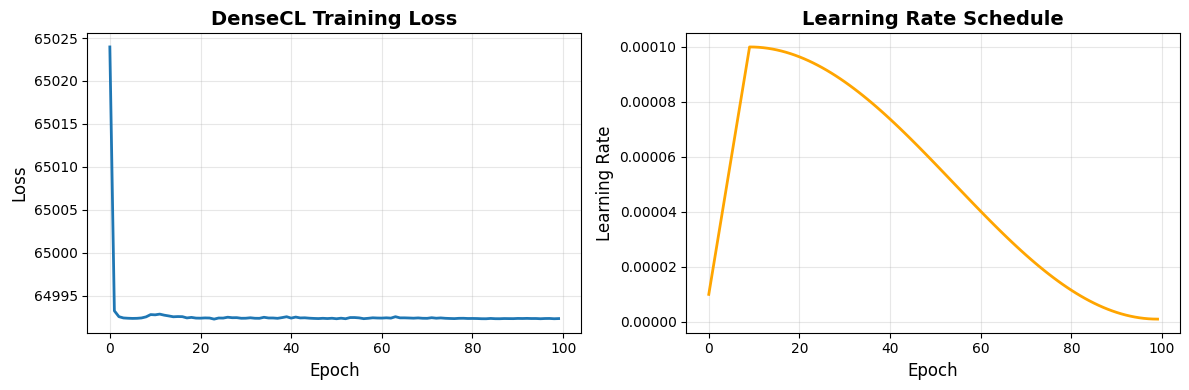

✅ Training history plotted!


In [11]:
# Cell 11: Plot Training History

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(densecl_history['train_loss'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('DenseCL Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Learning rate
plt.subplot(1, 2, 2)
plt.plot(densecl_history['lr'], linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/densecl_history.png', dpi=150)
plt.show()

print("✅ Training history plotted!")

In [12]:
# Cell 12: Segmentation Decoder with Skip Connections

class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
            nn.Dropout2d(0.1)
        )
    
    def forward(self, x):
        size = x.shape[2:]
        
        feat1 = self.conv1(x)
        feat2 = self.conv2(x)
        feat3 = self.conv3(x)
        feat4 = self.conv4(x)
        feat5 = F.interpolate(self.global_pool(x), size=size, mode='bilinear', align_corners=True)
        
        out = torch.cat([feat1, feat2, feat3, feat4, feat5], dim=1)
        out = self.fusion(out)
        
        return out


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, out_channels),
            nn.GELU()
        )
        
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False) \
                        if in_channels != out_channels else nn.Identity()
    
    def forward(self, x):
        return self.conv(x) + self.residual(x)


class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.1):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_channels + skip_channels, out_channels, dropout=dropout)
    
    def forward(self, x, skip):
        x = self.upsample(x)
        if skip is not None:
            if x.shape[2:] != skip.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class EnhancedSegmentationDecoder(nn.Module):
    def __init__(self, embed_dim=768, num_classes=4, dropout=0.2):
        super().__init__()
        
        self.proj = nn.Conv2d(embed_dim, 512, kernel_size=1)
        self.aspp = ASPP(512, 512)
        
        self.skip_proj_3 = nn.Conv2d(embed_dim, 256, kernel_size=1)
        self.skip_proj_2 = nn.Conv2d(embed_dim, 128, kernel_size=1)
        self.skip_proj_1 = nn.Conv2d(embed_dim, 64, kernel_size=1)
        
        self.dec4 = UpsampleBlock(512, 0, 256, dropout=dropout)
        self.dec3 = UpsampleBlock(256, 256, 128, dropout=dropout)
        self.dec2 = UpsampleBlock(128, 128, 64, dropout=dropout)
        self.dec1 = UpsampleBlock(64, 64, 32, dropout=dropout)
        
        self.aux_head_3 = nn.Conv2d(128, num_classes, kernel_size=1)
        self.aux_head_2 = nn.Conv2d(64, num_classes, kernel_size=1)
        
        self.seg_head = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, 32),
            nn.GELU(),
            nn.Dropout2d(dropout * 0.5),
            nn.Conv2d(32, num_classes, kernel_size=1)
        )
    
    def forward(self, x, skip_features=None, return_aux=False):
        B, N, D = x.shape
        H = W = int(N ** 0.5)
        
        x = x.transpose(1, 2).reshape(B, D, H, W)
        
        x = self.proj(x)
        x = self.aspp(x)
        
        skip_3 = None
        skip_2 = None
        skip_1 = None
        
        if skip_features is not None and len(skip_features) >= 3:
            skip_3 = self.skip_proj_3(skip_features[2])
            skip_2 = self.skip_proj_2(skip_features[1])
            skip_1 = self.skip_proj_1(skip_features[0])
        
        x4 = self.dec4(x, None)
        
        if skip_3 is not None:
            skip_3 = F.interpolate(skip_3, size=(16, 16), mode='bilinear', align_corners=True)
        x3 = self.dec3(x4, skip_3)
        aux_3 = self.aux_head_3(x3) if return_aux else None
        
        if skip_2 is not None:
            skip_2 = F.interpolate(skip_2, size=(32, 32), mode='bilinear', align_corners=True)
        x2 = self.dec2(x3, skip_2)
        aux_2 = self.aux_head_2(x2) if return_aux else None
        
        if skip_1 is not None:
            skip_1 = F.interpolate(skip_1, size=(64, 64), mode='bilinear', align_corners=True)
        x1 = self.dec1(x2, skip_1)
        
        out = self.seg_head(x1)
        
        if return_aux:
            return out, [aux_3, aux_2]
        return out

print("✅ Segmentation decoder defined!")

✅ Segmentation decoder defined!


In [13]:
# Cell 13: Segmentation Model with DenseCL Pretrained Encoder

class ViTEncoderWithSkips(nn.Module):
    def __init__(self, num_patches=64, embed_dim=768, num_layers=12, 
                 num_heads=12, mlp_ratio=4.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.num_patches = num_patches
        
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                dropout=0.1,
                activation='gelu',
                batch_first=True,
                norm_first=True
            )
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
    def forward(self, x, return_skips=False):
        x = x + self.pos_embed
        
        skip_features = []
        skip_layers = [3, 6, 9]
        
        for idx, block in enumerate(self.blocks):
            x = block(x)
            
            if return_skips and idx in skip_layers:
                skip_features.append(x.clone())
        
        x = self.norm(x)
        
        if return_skips:
            skip_spatial = []
            for skip in skip_features:
                B, N, D = skip.shape
                H = W = int(N ** 0.5)
                skip_spatial.append(skip.transpose(1, 2).reshape(B, D, H, W))
            
            return x, skip_spatial
        
        return x


class DenseCLSegmentationModel(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=4, num_classes=4,
                 embed_dim=768, num_layers=12, num_heads=12, mlp_ratio=4.0,
                 dropout=0.2, pretrained_encoder_path=None):
        super().__init__()
        
        self.num_patches = (img_size // patch_size) ** 2
        
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        
        self.encoder = ViTEncoderWithSkips(self.num_patches, embed_dim, num_layers, num_heads, mlp_ratio)
        
        if pretrained_encoder_path is not None:
            print(f"Loading DenseCL pretrained encoder from {pretrained_encoder_path}")
            try:
                pretrained_dict = torch.load(pretrained_encoder_path, map_location='cpu')
                encoder_dict = self.encoder.state_dict()
                pretrained_dict_filtered = {
                    k: v for k, v in pretrained_dict.items() 
                    if k in encoder_dict and v.shape == encoder_dict[k].shape
                }
                encoder_dict.update(pretrained_dict_filtered)
                self.encoder.load_state_dict(encoder_dict, strict=False)
                print(f"✅ Loaded {len(pretrained_dict_filtered)} layers from DenseCL encoder")
            except Exception as e:
                print(f"⚠️ Could not load pretrained encoder: {e}")
        
        self.decoder = EnhancedSegmentationDecoder(embed_dim, num_classes, dropout=dropout)
        
        print("DenseCL Segmentation Model initialized:")
        print(f"  Image size: {img_size}x{img_size}")
        print(f"  Num patches: {self.num_patches}")
        print(f"  Pretrained: {'Yes (DenseCL)' if pretrained_encoder_path else 'No'}")
    
    def forward(self, x, return_aux=False):
        x = self.patch_embed(x)
        x, skip_features = self.encoder(x, return_skips=True)
        
        if return_aux:
            out, aux_outputs = self.decoder(x, skip_features, return_aux=True)
            return out, aux_outputs
        else:
            out = self.decoder(x, skip_features, return_aux=False)
            return out
    
    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False
        print("🔒 Encoder frozen")
    
    def unfreeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = True
        print("🔓 Encoder unfrozen")


# Create segmentation model
seg_model = DenseCLSegmentationModel(
    img_size=config.IMG_SIZE,
    patch_size=config.PATCH_SIZE,
    in_channels=config.CHANNELS,
    num_classes=config.NUM_CLASSES,
    embed_dim=config.EMBED_DIM,
    num_layers=config.NUM_LAYERS,
    num_heads=config.NUM_HEADS,
    mlp_ratio=config.MLP_RATIO,
    dropout=config.FT_DROPOUT,
    pretrained_encoder_path='/kaggle/working/densecl_encoder_pretrained.pth'
).to(device)

total_params = sum(p.numel() for p in seg_model.parameters())
trainable_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)

print(f"\n✅ Segmentation Model Created!")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

Loading DenseCL pretrained encoder from /kaggle/working/densecl_encoder_pretrained.pth
✅ Loaded 147 layers from DenseCL encoder
DenseCL Segmentation Model initialized:
  Image size: 128x128
  Num patches: 64
  Pretrained: Yes (DenseCL)

✅ Segmentation Model Created!
   Total parameters: 98,515,980
   Trainable parameters: 98,515,980


In [14]:
# Cell 14: Segmentation Dataset with Strong Augmentation

class SegmentationDataset(Dataset):
    """Enhanced dataset with STRONG augmentation for fine-tuning"""
    def __init__(self, images, masks, augment=False):
        self.images = images
        self.masks = masks
        self.augment = augment
    
    def elastic_transform(self, image, mask, alpha=15, sigma=3):
        """Elastic deformation"""
        from scipy.ndimage import gaussian_filter, map_coordinates
        
        shape = image.shape[:2]
        dx = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
        
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = (y + dy).reshape(-1), (x + dx).reshape(-1)
        
        image_deformed = np.zeros_like(image)
        for c in range(image.shape[-1]):
            image_deformed[:, :, c] = map_coordinates(
                image[:, :, c], indices, order=1, mode='reflect'
            ).reshape(shape)
        
        mask_deformed = map_coordinates(
            mask, indices, order=0, mode='reflect'
        ).reshape(shape)
        
        return image_deformed, mask_deformed
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx].copy()
        mask = self.masks[idx].copy()
        
        if self.augment:
            # Horizontal flip
            if np.random.rand() > 0.5:
                image = np.fliplr(image)
                mask = np.fliplr(mask)
            
            # Vertical flip
            if np.random.rand() > 0.5:
                image = np.flipud(image)
                mask = np.flipud(mask)
            
            # Random rotation
            if np.random.rand() > 0.25:
                k = np.random.choice([1, 2, 3])
                image = np.rot90(image, k, axes=(0, 1))
                mask = np.rot90(mask, k, axes=(0, 1))
            
            # Elastic deformation
            if np.random.rand() > 0.6:
                image, mask = self.elastic_transform(image, mask, alpha=15, sigma=3)
            
            # Random scaling
            if np.random.rand() > 0.7:
                scale = np.random.uniform(0.9, 1.1)
                new_size = int(128 * scale)
                if new_size != 128:
                    image_scaled = cv2.resize(image, (new_size, new_size))
                    mask_scaled = cv2.resize(mask, (new_size, new_size), 
                                           interpolation=cv2.INTER_NEAREST)
                    
                    if new_size > 128:
                        start = (new_size - 128) // 2
                        image = image_scaled[start:start+128, start:start+128]
                        mask = mask_scaled[start:start+128, start:start+128]
                    else:
                        pad = (128 - new_size) // 2
                        image = np.pad(image_scaled, 
                                     ((pad, 128-new_size-pad), (pad, 128-new_size-pad), (0, 0)),
                                     mode='reflect')
                        mask = np.pad(mask_scaled,
                                    ((pad, 128-new_size-pad), (pad, 128-new_size-pad)),
                                    mode='reflect')
            
            # Brightness and contrast per channel
            if np.random.rand() > 0.4:
                for c in range(image.shape[-1]):
                    beta = np.random.uniform(-0.15, 0.15)
                    image[:, :, c] = image[:, :, c] + beta
                    
                    alpha = np.random.uniform(0.85, 1.15)
                    mean = np.mean(image[:, :, c])
                    image[:, :, c] = alpha * (image[:, :, c] - mean) + mean
            
            # Gaussian noise
            if np.random.rand() > 0.6:
                noise = np.random.normal(0, 0.05, image.shape)
                image = image + noise
            
            # Gaussian blur
            if np.random.rand() > 0.7:
                from scipy.ndimage import gaussian_filter
                sigma = np.random.uniform(0.5, 1.5)
                for c in range(image.shape[-1]):
                    image[:, :, c] = gaussian_filter(image[:, :, c], sigma=sigma)
            
            # Gamma correction
            if np.random.rand() > 0.75:
                gamma = np.random.uniform(0.8, 1.2)
                for c in range(image.shape[-1]):
                    img_min = image[:, :, c].min()
                    img_max = image[:, :, c].max()
                    if img_max > img_min:
                        img_norm = (image[:, :, c] - img_min) / (img_max - img_min)
                        img_gamma = np.power(img_norm, gamma)
                        image[:, :, c] = img_gamma * (img_max - img_min) + img_min
            
            # Random channel shuffle
            if np.random.rand() > 0.85:
                channels = np.random.permutation(4)
                image = image[:, :, channels]
            
            image = np.clip(image, -3, 3)
        
        image = torch.from_numpy(image.copy()).float().permute(2, 0, 1)
        mask = torch.from_numpy(mask.copy()).long()
        mask = torch.clamp(mask, 0, config.NUM_CLASSES - 1)
        
        return image, mask


# Create datasets
train_dataset = SegmentationDataset(X_train, y_train, augment=True)
val_dataset = SegmentationDataset(X_val, y_val, augment=False)
test_dataset = SegmentationDataset(X_test, y_test, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.FT_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Segmentation datasets created!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ Segmentation datasets created!
   Train batches: 1779
   Val batches: 375
   Test batches: 375


In [15]:
# Cell 15: Loss Functions and Metrics

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        num_classes = pred.shape[1]
        target = torch.clamp(target, 0, num_classes - 1)
        target_one_hot = F.one_hot(target.long(), num_classes).permute(0, 3, 1, 2).float()
        pred = F.softmax(pred, dim=1)
        
        dice_sum = 0
        for i in range(num_classes):
            pred_i = pred[:, i].flatten()
            target_i = target_one_hot[:, i].flatten()
            intersection = (pred_i * target_i).sum()
            dice = (2. * intersection + self.smooth) / (pred_i.sum() + target_i.sum() + self.smooth)
            dice_sum += dice
        
        return 1 - dice_sum / num_classes


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, pred, target):
        num_classes = pred.shape[1]
        target = torch.clamp(target, 0, num_classes - 1).long()
        ce_loss = F.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class EnhancedCombinedLoss(nn.Module):
    def __init__(self, label_smoothing=0.1):
        super().__init__()
        self.dice_loss = DiceLoss()
        self.focal_loss = FocalLoss()
        self.class_weights = torch.tensor([0.5, 1.5, 1.5, 2.0]).to(device)
        self.label_smoothing = label_smoothing
    
    def forward(self, pred, target, aux_outputs=None):
        dice = self.dice_loss(pred, target)
        focal = self.focal_loss(pred, target)
        ce = F.cross_entropy(
            pred, target,
            weight=self.class_weights,
            label_smoothing=self.label_smoothing
        )
        
        main_loss = 0.5 * dice + 0.3 * focal + 0.2 * ce
        
        if aux_outputs is not None:
            aux_loss = 0
            aux_weights = [0.5, 0.3]
            
            for aux_pred, weight in zip(aux_outputs, aux_weights):
                target_resized = F.interpolate(
                    target.unsqueeze(1).float(),
                    size=aux_pred.shape[2:],
                    mode='nearest'
                ).squeeze(1).long()
                
                aux_dice = self.dice_loss(aux_pred, target_resized)
                aux_ce = F.cross_entropy(aux_pred, target_resized, weight=self.class_weights)
                aux_loss += weight * (0.7 * aux_dice + 0.3 * aux_ce)
            
            total_loss = 0.7 * main_loss + 0.3 * aux_loss
            return total_loss
        
        return main_loss


def calculate_dice_score(pred, target, num_classes=4):
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    dice_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum()).item()
        
        if union == 0:
            dice_scores.append(1.0)
        else:
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            dice_scores.append(dice)
    
    return np.mean(dice_scores)


def calculate_iou_score(pred, target, num_classes=4):
    pred = torch.argmax(pred, dim=1)
    target = torch.clamp(target, 0, num_classes - 1)
    
    iou_scores = []
    for i in range(num_classes):
        pred_i = (pred == i).float()
        target_i = (target == i).float()
        intersection = (pred_i * target_i).sum().item()
        union = (pred_i.sum() + target_i.sum() - intersection).item()
        
        if union == 0:
            iou_scores.append(1.0)
        else:
            iou = (intersection + 1e-6) / (union + 1e-6)
            iou_scores.append(iou)
    
    return np.mean(iou_scores)

print("✅ Loss functions and metrics defined!")

✅ Loss functions and metrics defined!


In [16]:
# Cell 16: Training Functions

def train_epoch(model, dataloader, criterion, optimizer, device, use_deep_supervision=True):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Training')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        if use_deep_supervision:
            outputs, aux_outputs = model(images, return_aux=True)
            loss = criterion(outputs, masks, aux_outputs)
        else:
            outputs = model(images, return_aux=False)
            loss = criterion(outputs, masks)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.GRADIENT_CLIP)
        optimizer.step()
        
        with torch.no_grad():
            dice = calculate_dice_score(outputs.detach(), masks)
            iou = calculate_iou_score(outputs.detach(), masks)
        
        running_loss += loss.item()
        running_dice += dice
        running_iou += iou
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice:.4f}',
            'iou': f'{iou:.4f}'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    pbar = tqdm(dataloader, desc='Validation')
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images, return_aux=False)
            loss = criterion(outputs, masks)
            
            dice = calculate_dice_score(outputs, masks)
            iou = calculate_iou_score(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice:.4f}',
                'iou': f'{iou:.4f}'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou

print("✅ Training functions defined!")

✅ Training functions defined!


In [17]:
# Cell 17: Two-Stage Fine-tuning

print("\n" + "="*70)
print("PHASE 2: FINE-TUNING WITH DenseCL PRETRAINED ENCODER")
print("="*70)
print(f"Total epochs: {config.FT_EPOCHS}")
print(f"Stage 1 (freeze encoder): {config.FT_FREEZE_EPOCHS} epochs")
print(f"Stage 2 (unfreeze encoder): {config.FT_EPOCHS - config.FT_FREEZE_EPOCHS} epochs")
print(f"\nREGULARIZATION:")
print(f"  Weight Decay: {config.FT_WEIGHT_DECAY}")
print(f"  Dropout: {config.FT_DROPOUT}")
print(f"  Label Smoothing: {config.FT_LABEL_SMOOTHING}")
print(f"  Deep Supervision: Enabled")
print("="*70)

criterion = EnhancedCombinedLoss(label_smoothing=config.FT_LABEL_SMOOTHING)

# Stage 1 optimizer (decoder only)
optimizer_stage1 = optim.AdamW(
    seg_model.decoder.parameters(),
    lr=config.FT_LEARNING_RATE_DECODER,
    weight_decay=config.FT_WEIGHT_DECAY
)

# Stage 2 optimizer (encoder + decoder with differential LR)
optimizer_stage2 = optim.AdamW([
    {'params': seg_model.encoder.parameters(), 'lr': config.FT_LEARNING_RATE_ENCODER},
    {'params': seg_model.decoder.parameters(), 'lr': config.FT_LEARNING_RATE_DECODER}
], weight_decay=config.FT_WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode='max',
    factor=0.5,
    patience=7,
    verbose=True,
    min_lr=1e-8
)

ft_history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': []
}

best_val_dice = 0.0
patience_counter = 0
ft_start_time = time.time()

# ========== STAGE 1: FREEZE ENCODER ==========
print("\n" + "="*70)
print(f"STAGE 1: TRAINING DECODER ONLY ({config.FT_FREEZE_EPOCHS} EPOCHS)")
print("="*70)
seg_model.freeze_encoder()

for epoch in range(config.FT_FREEZE_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{config.FT_FREEZE_EPOCHS} (Stage 1 - Encoder Frozen)")
    print(f"{'='*70}")
    
    train_loss, train_dice, train_iou = train_epoch(
        seg_model, train_loader, criterion, optimizer_stage1, device,
        use_deep_supervision=True
    )
    
    val_loss, val_dice, val_iou = validate_epoch(
        seg_model, val_loader, criterion, device
    )
    
    ft_history['train_loss'].append(train_loss)
    ft_history['train_dice'].append(train_dice)
    ft_history['train_iou'].append(train_iou)
    ft_history['val_loss'].append(val_loss)
    ft_history['val_dice'].append(val_dice)
    ft_history['val_iou'].append(val_iou)
    
    gap = abs(train_dice - val_dice)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
    print(f"  Gap   - Dice: {gap:.4f} ({'✅ Healthy' if gap < 0.05 else '⚠️ Watch' if gap < 0.10 else '❌ Overfitting'})")
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': seg_model.state_dict(),
            'optimizer_state_dict': optimizer_stage1.state_dict(),
            'val_dice': val_dice,
        }, '/kaggle/working/seg_model_best.pth')
        print(f"  ✅ Best model saved! (Val Dice: {val_dice:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

# ========== STAGE 2: UNFREEZE WITH VERY LOW LR ==========
print("\n" + "="*70)
print(f"STAGE 2: FINE-TUNING ENCODER WITH LOW LR")
print(f"  Encoder LR: {config.FT_LEARNING_RATE_ENCODER:.2e} (VERY LOW)")
print(f"  Decoder LR: {config.FT_LEARNING_RATE_DECODER:.2e}")
print("="*70)
seg_model.unfreeze_encoder()

for epoch in range(config.FT_FREEZE_EPOCHS, config.FT_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{config.FT_EPOCHS} (Stage 2 - Encoder Unfrozen)")
    print(f"{'='*70}")
    
    train_loss, train_dice, train_iou = train_epoch(
        seg_model, train_loader, criterion, optimizer_stage2, device,
        use_deep_supervision=True
    )
    
    val_loss, val_dice, val_iou = validate_epoch(
        seg_model, val_loader, criterion, device
    )
    
    scheduler.step(val_dice)
    current_lr_enc = optimizer_stage2.param_groups[0]['lr']
    current_lr_dec = optimizer_stage2.param_groups[1]['lr']
    
    ft_history['train_loss'].append(train_loss)
    ft_history['train_dice'].append(train_dice)
    ft_history['train_iou'].append(train_iou)
    ft_history['val_loss'].append(val_loss)
    ft_history['val_dice'].append(val_dice)
    ft_history['val_iou'].append(val_iou)
    
    gap = abs(train_dice - val_dice)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
    print(f"  Gap   - Dice: {gap:.4f} ({'✅ Healthy' if gap < 0.05 else '⚠️ Watch' if gap < 0.10 else '❌ Overfitting'})")
    print(f"  LR    - Encoder: {current_lr_enc:.2e}, Decoder: {current_lr_dec:.2e}")
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': seg_model.state_dict(),
            'optimizer_state_dict': optimizer_stage2.state_dict(),
            'val_dice': val_dice,
        }, '/kaggle/working/seg_model_best.pth')
        print(f"  ✅ Best model saved! (Val Dice: {val_dice:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= config.FT_PATIENCE:
        print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
        print(f"   Val Dice hasn't improved for {config.FT_PATIENCE} epochs")
        break

ft_total_time = time.time() - ft_start_time

print("\n" + "="*70)
print("✅ FINE-TUNING COMPLETED!")
print("="*70)
print(f"Total time: {ft_total_time / 3600:.2f} hours")
print(f"Best validation Dice: {best_val_dice:.4f}")
print(f"Final train-val gap: {abs(ft_history['train_dice'][-1] - ft_history['val_dice'][-1]):.4f}")
print("="*70)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



PHASE 2: FINE-TUNING WITH DenseCL PRETRAINED ENCODER
Total epochs: 50
Stage 1 (freeze encoder): 30 epochs
Stage 2 (unfreeze encoder): 20 epochs

REGULARIZATION:
  Weight Decay: 0.01
  Dropout: 0.2
  Label Smoothing: 0.1
  Deep Supervision: Enabled

STAGE 1: TRAINING DECODER ONLY (30 EPOCHS)
🔒 Encoder frozen

Epoch 1/30 (Stage 1 - Encoder Frozen)


Validation: 100%|██████████| 375/375 [00:20<00:00, 18.02it/s, loss=0.5752, dice=0.7475, iou=0.7450]



Epoch 1 Summary:
  Train - Loss: 0.5796, Dice: 0.2468, IoU: 0.2431
  Val   - Loss: 0.5817, Dice: 0.3673, IoU: 0.3634
  Gap   - Dice: 0.1205 (❌ Overfitting)
  ✅ Best model saved! (Val Dice: 0.3673)

Epoch 2/30 (Stage 1 - Encoder Frozen)


Validation: 100%|██████████| 375/375 [00:20<00:00, 18.02it/s, loss=0.5732, dice=0.7487, iou=0.7456]


...


Epoch 48 Summary:
  Train - Loss: 0.5012, Dice: 0.4386, IoU: 0.3614
  Val   - Loss: 0.5508, Dice: 0.4577, IoU: 0.4057
  Gap   - Dice: 0.0191 (✅ Healthy)
  LR    - Encoder: 5.00e-07, Decoder: 1.00e-04

Epoch 49/50 (Stage 2 - Encoder Unfrozen)


Validation: 100%|██████████| 375/375 [00:20<00:00, 18.07it/s, loss=0.5536, dice=0.8631, iou=0.8209]



Epoch 49 Summary:
  Train - Loss: 0.4999, Dice: 0.4425, IoU: 0.3642
  Val   - Loss: 0.5509, Dice: 0.4474, IoU: 0.3930
  Gap   - Dice: 0.0050 (✅ Healthy)
  LR    - Encoder: 2.50e-07, Decoder: 5.00e-05

Epoch 50/50 (Stage 2 - Encoder Unfrozen)


Validation: 100%|██████████| 375/375 [00:20<00:00, 18.11it/s, loss=0.5421, dice=0.8999, iou=0.8556]


Epoch 50 Summary:
  Train - Loss: 0.4971, Dice: 0.4538, IoU: 0.3719
  Val   - Loss: 0.5489, Dice: 0.4603, IoU: 0.4068
  Gap   - Dice: 0.0065 (✅ Healthy)
  LR    - Encoder: 2.50e-07, Decoder: 5.00e-05

✅ FINE-TUNING COMPLETED!
Total time: 5.23 hours
Best validation Dice: 0.4640
Final train-val gap: 0.0065


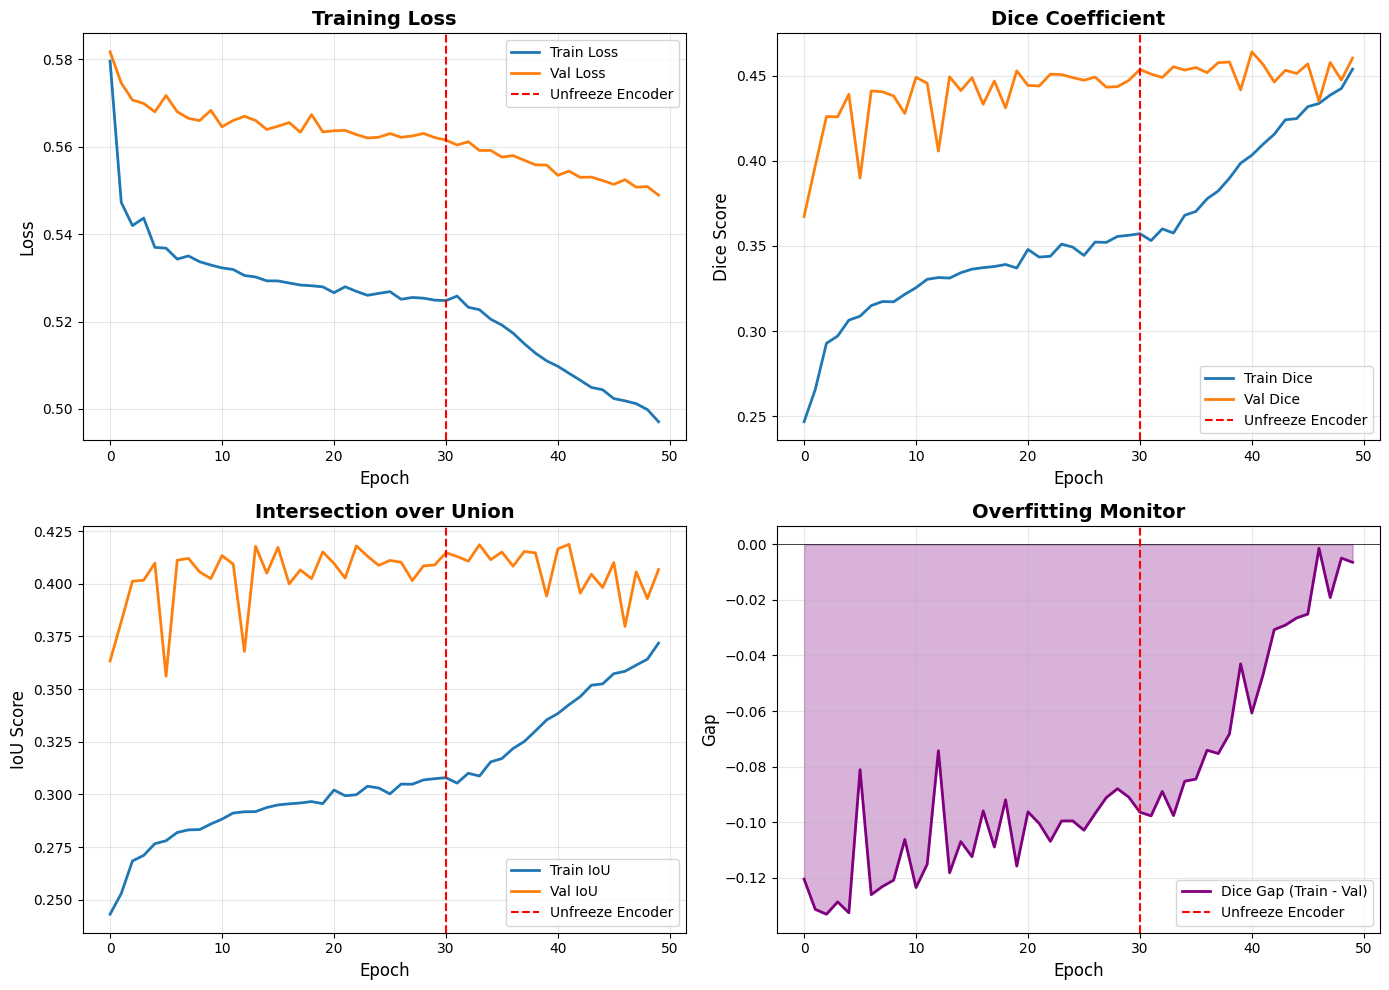

✅ Training history plotted!


In [18]:
# Cell 18: Plot Fine-tuning History

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(ft_history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(ft_history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice
axes[0, 1].plot(ft_history['train_dice'], label='Train Dice', linewidth=2)
axes[0, 1].plot(ft_history['val_dice'], label='Val Dice', linewidth=2)
axes[0, 1].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Dice Score', fontsize=12)
axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[1, 0].plot(ft_history['train_iou'], label='Train IoU', linewidth=2)
axes[1, 0].plot(ft_history['val_iou'], label='Val IoU', linewidth=2)
axes[1, 0].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('IoU Score', fontsize=12)
axes[1, 0].set_title('Intersection over Union', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Train-Val Gap
gap = np.array(ft_history['train_dice']) - np.array(ft_history['val_dice'])
axes[1, 1].plot(gap, label='Dice Gap (Train - Val)', linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(x=config.FT_FREEZE_EPOCHS, color='red', linestyle='--', 
                   label='Unfreeze Encoder', linewidth=1.5)
axes[1, 1].fill_between(range(len(gap)), 0, gap, alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Gap', fontsize=12)
axes[1, 1].set_title('Overfitting Monitor', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history plotted!")

In [1]:
# =========================
# Cell 19: Test Set Evaluation (FIXED)
# =========================

print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model - FIXED for PyTorch 2.6+
try:
    # Try loading with weights_only=True first (safer)
    checkpoint = torch.load('/kaggle/working/seg_model_best.pth', 
                           weights_only=True,
                           map_location=device)
    print("✅ Loaded checkpoint with weights_only=True")
except Exception as e:
    # Fallback to weights_only=False if needed
    print(f"⚠️ weights_only=True failed, using weights_only=False")
    print(f"   Error: {str(e)[:100]}...")
    checkpoint = torch.load('/kaggle/working/seg_model_best.pth', 
                           weights_only=False,
                           map_location=device)

# Load model state
seg_model.load_state_dict(checkpoint['model_state_dict'])
seg_model.eval()

print(f"✅ Model loaded from epoch {checkpoint.get('epoch', 'unknown')}")
print(f"   Best validation dice: {checkpoint.get('best_dice', 'unknown')}")

# Initialize metrics
test_loss = 0.0
test_dice = 0.0
test_iou = 0.0
num_batches = 0

print("\nEvaluating on test set...")

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = seg_model(images, return_aux=False)
        
        # Calculate metrics
        loss = criterion(outputs, masks)
        dice = calculate_dice_score(outputs, masks)
        iou = calculate_iou_score(outputs, masks)
        
        # Accumulate
        test_loss += loss.item()
        test_dice += dice
        test_iou += iou
        num_batches += 1

# Average metrics
test_loss /= num_batches
test_dice /= num_batches
test_iou /= num_batches

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f} ({test_dice*100:.2f}%)")
print(f"Test IoU: {test_iou:.4f} ({test_iou*100:.2f}%)")
print("="*70)

# Save results
results = {
    'densecl_pretraining': {
        'epochs': config.DENSECL_EPOCHS,
        'final_loss': float(densecl_history['train_loss'][-1]),  # Convert to float
        'best_loss': float(best_loss) if isinstance(best_loss, (np.ndarray, np.number)) else best_loss
    },
    'fine_tuning': {
        'total_epochs': len(ft_history['train_loss']),
        'stage1_epochs': config.FT_FREEZE_EPOCHS,
        'best_val_dice': float(best_val_dice) if isinstance(best_val_dice, (np.ndarray, np.number)) else best_val_dice,
        'final_train_dice': float(ft_history['train_dice'][-1]),
        'final_val_dice': float(ft_history['val_dice'][-1]),
        'final_gap': float(abs(ft_history['train_dice'][-1] - ft_history['val_dice'][-1]))
    },
    'test_results': {
        'loss': float(test_loss),
        'dice': float(test_dice),
        'iou': float(test_iou)
    },
    'data_split': {
        'train_patients': len(train_patients),
        'val_patients': len(val_patients),
        'test_patients': len(test_patients),
        'ssl_patients': len(ssl_patients)
    }
}

import json
with open('/kaggle/working/densecl_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\n✅ Results saved to densecl_results.json")

# Also save as readable text file
with open('/kaggle/working/densecl_results.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("DENSECL + VISION TRANSFORMER - FINAL RESULTS\n")
    f.write("="*70 + "\n\n")
    
    f.write("SSL PRETRAINING (DenseCL):\n")
    f.write(f"  Epochs: {results['densecl_pretraining']['epochs']}\n")
    f.write(f"  Final Loss: {results['densecl_pretraining']['final_loss']:.4f}\n")
    f.write(f"  Best Loss: {results['densecl_pretraining']['best_loss']:.4f}\n\n")
    
    f.write("FINE-TUNING:\n")
    f.write(f"  Total Epochs: {results['fine_tuning']['total_epochs']}\n")
    f.write(f"  Stage 1 (Frozen): {results['fine_tuning']['stage1_epochs']} epochs\n")
    f.write(f"  Best Val Dice: {results['fine_tuning']['best_val_dice']:.4f}\n")
    f.write(f"  Final Train Dice: {results['fine_tuning']['final_train_dice']:.4f}\n")
    f.write(f"  Final Val Dice: {results['fine_tuning']['final_val_dice']:.4f}\n")
    f.write(f"  Train-Val Gap: {results['fine_tuning']['final_gap']:.4f}\n\n")
    
    f.write("TEST SET RESULTS:\n")
    f.write(f"  Loss: {results['test_results']['loss']:.4f}\n")
    f.write(f"  Dice: {results['test_results']['dice']:.4f} ({results['test_results']['dice']*100:.2f}%)\n")
    f.write(f"  IoU: {results['test_results']['iou']:.4f} ({results['test_results']['iou']*100:.2f}%)\n\n")
    
    f.write("DATA SPLIT:\n")
    f.write(f"  SSL Patients: {results['data_split']['ssl_patients']}\n")
    f.write(f"  Train Patients: {results['data_split']['train_patients']}\n")
    f.write(f"  Val Patients: {results['data_split']['val_patients']}\n")
    f.write(f"  Test Patients: {results['data_split']['test_patients']}\n\n")
    
    f.write("="*70 + "\n")

print("✅ Results also saved to densecl_results.txt")


TEST SET EVALUATION
⚠️ weights_only=True failed, using weights_only=False
   Error: name 'torch' is not defined...


NameError: name 'torch' is not defined

In [ ]:
# Cell 20: Visualize Predictions

def plot_predictions(model, dataset, num_samples=8):
    """Plot predictions"""
    model.eval()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            pred_logits = model(image_input, return_aux=False)
            pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            # Convert to numpy
            image_np = image.permute(1, 2, 0).numpy()
            mask_np = mask.numpy()
            
            # Create colored masks
            mask_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_colored[mask_np == c] = colors[c]
                pred_colored[pred == c] = colors[c]
            
            # Plot
            img_display = image_np[:, :, 0]  # FLAIR channel
            
            axes[i, 0].imshow(img_display, cmap='gray')
            axes[i, 0].set_title('Input Image (FLAIR)', fontsize=10)
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_colored)
            axes[i, 1].set_title('Ground Truth', fontsize=10)
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred_colored)
            axes[i, 2].set_title('Prediction', fontsize=10)
            axes[i, 2].axis('off')
            
            # Overlay
            img_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            overlay = np.stack([img_norm, img_norm, img_norm], axis=-1)
            alpha = 0.4
            overlay = (1 - alpha) * overlay + alpha * (pred_colored / 255.0)
            
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay', fontsize=10)
            axes[i, 3].axis('off')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i]/255, label=class_names[i]) for i in range(4)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=11, frameon=True)
    
    plt.suptitle('DenseCL-ViT Segmentation Results', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('/kaggle/working/predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(seg_model, test_dataset, num_samples=8)
print("✅ Predictions visualized!")

In [ ]:
# Cell 21: Detailed Class-wise Metrics

def compute_class_wise_metrics(model, dataloader, device):
    """Compute detailed class-wise metrics"""
    
    model.eval()
    
    print("Computing predictions...")
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Predicting'):
            images = images.to(device)
            
            outputs = model(images, return_aux=False)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            
            all_preds.append(preds)
            all_true.append(masks.numpy())
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    
    # Compute class-wise metrics
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    num_classes = 4
    
    class_metrics = {
        'Class': [],
        'Dice': [],
        'IoU': [],
        'Precision': [],
        'Recall': [],
        'F1-Score': [],
        'Pixel Count': []
    }
    
    print("\nComputing class-wise metrics...")
    
    for class_id in range(num_classes):
        pred_binary = (all_preds == class_id).astype(np.float32)
        true_binary = (all_true == class_id).astype(np.float32)
        
        pred_flat = pred_binary.flatten()
        true_flat = true_binary.flatten()
        
        tp = np.sum((pred_flat == 1) & (true_flat == 1))
        fp = np.sum((pred_flat == 1) & (true_flat == 0))
        fn = np.sum((pred_flat == 0) & (true_flat == 1))
        tn = np.sum((pred_flat == 0) & (true_flat == 0))
        
        dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
        pixel_count = np.sum(true_flat == 1)
        
        class_metrics['Class'].append(class_names[class_id])
        class_metrics['Dice'].append(dice)
        class_metrics['IoU'].append(iou)
        class_metrics['Precision'].append(precision)
        class_metrics['Recall'].append(recall)
        class_metrics['F1-Score'].append(f1)
        class_metrics['Pixel Count'].append(pixel_count)
    
    return class_metrics, all_preds, all_true


# Compute metrics
class_metrics, all_preds, all_true = compute_class_wise_metrics(
    seg_model, test_loader, device
)

# Create DataFrame
df_metrics = pd.DataFrame(class_metrics)

print("\n" + "="*70)
print("CLASS-WISE PERFORMANCE METRICS")
print("="*70)
print(df_metrics.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print("="*70)

# Save to CSV
df_metrics.to_csv('/kaggle/working/class_wise_metrics.csv', index=False)
print(f"\n✅ Metrics saved to: class_wise_metrics.csv")

In [ ]:
# Cell 22: Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    
    # Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, ax=axes[0],
                square=True, linewidths=1, linecolor='black')
    axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Proportion'}, ax=axes[1],
                square=True, linewidths=1, linecolor='black', vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Classification report
    print("\n" + "="*70)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*70)
    report = classification_report(
        y_true_flat, 
        y_pred_flat, 
        target_names=class_names,
        digits=4
    )
    print(report)
    print("="*70)
    
    # Save report
    with open('/kaggle/working/classification_report.txt', 'w') as f:
        f.write(report)
    
    return cm, cm_normalized


cm, cm_normalized = plot_confusion_matrix(all_true, all_preds)

print(f"✅ Confusion matrix saved to: confusion_matrix.png")

In [ ]:
# Cell 23: Detailed Error Map Analysis

def create_error_maps(model, dataset, device, num_samples=10):
    """Create detailed error maps"""
    
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig = plt.figure(figsize=(20, num_samples * 4))
    gs = fig.add_gridspec(num_samples, 6, hspace=0.3, wspace=0.3)
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    colors = np.array([[0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask_true = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            pred_logits = model(image_input, return_aux=False)
            mask_pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            mask_true_np = mask_true.numpy()
            image_np = image.permute(1, 2, 0).numpy()
            
            # Create error map
            error_map = np.zeros_like(mask_true_np, dtype=np.uint8)
            
            correct = (mask_pred == mask_true_np)
            fp = (mask_pred > 0) & (mask_true_np == 0)
            fn = (mask_pred == 0) & (mask_true_np > 0)
            misclass = (mask_pred != mask_true_np) & (mask_pred > 0) & (mask_true_np > 0)
            
            error_map[correct] = 0
            error_map[fp] = 1
            error_map[fn] = 2
            error_map[misclass] = 3
            
            # Create colored visualizations
            mask_true_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            mask_pred_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            
            for c in range(4):
                mask_true_colored[mask_true_np == c] = colors[c]
                mask_pred_colored[mask_pred == c] = colors[c]
            
            # Error colors
            error_colors = np.array([
                [255, 255, 255],  # Correct - White
                [255, 255, 0],    # False Positive - Yellow
                [255, 0, 255],    # False Negative - Magenta
                [255, 165, 0]     # Misclassification - Orange
            ])
            
            error_map_colored = np.zeros((config.IMG_SIZE, config.IMG_SIZE, 3), dtype=np.uint8)
            for c in range(4):
                error_map_colored[error_map == c] = error_colors[c]
            
            # Input image
            img_display = image_np[:, :, 0]
            img_display_norm = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            
            # Plot
            ax1 = fig.add_subplot(gs[i, 0])
            ax1.imshow(img_display, cmap='gray')
            ax1.set_title('Input (FLAIR)', fontsize=10, fontweight='bold')
            ax1.axis('off')
            
            ax2 = fig.add_subplot(gs[i, 1])
            ax2.imshow(mask_true_colored)
            ax2.set_title('Ground Truth', fontsize=10, fontweight='bold')
            ax2.axis('off')
            
            ax3 = fig.add_subplot(gs[i, 2])
            ax3.imshow(mask_pred_colored)
            ax3.set_title('Prediction', fontsize=10, fontweight='bold')
            ax3.axis('off')
            
            ax4 = fig.add_subplot(gs[i, 3])
            ax4.imshow(error_map_colored)
            ax4.set_title('Error Map', fontsize=10, fontweight='bold')
            ax4.axis('off')
            
            # Overlay
            ax5 = fig.add_subplot(gs[i, 4])
            overlay = np.stack([img_display_norm, img_display_norm, img_display_norm], axis=-1)
            alpha = 0.5
            overlay_error = (1 - alpha) * overlay + alpha * (error_map_colored / 255.0)
            ax5.imshow(overlay_error)
            ax5.set_title('Error Overlay', fontsize=10, fontweight='bold')
            ax5.axis('off')
            
            # Dice scores per class
            ax6 = fig.add_subplot(gs[i, 5])
            dice_scores = []
            for c in range(1, 4):
                pred_c = (mask_pred == c).astype(np.float32)
                true_c = (mask_true_np == c).astype(np.float32)
                
                intersection = np.sum(pred_c * true_c)
                dice = (2 * intersection) / (np.sum(pred_c) + np.sum(true_c) + 1e-7)
                dice_scores.append(dice)
            
            bars = ax6.barh(class_names[1:], dice_scores, color=['red', 'green', 'blue'])
            ax6.set_xlim(0, 1)
            ax6.set_xlabel('Dice Score', fontsize=9)
            ax6.set_title('Class-wise Dice', fontsize=10, fontweight='bold')
            ax6.grid(axis='x', alpha=0.3)
            
            for bar, score in zip(bars, dice_scores):
                width = bar.get_width()
                ax6.text(width, bar.get_y() + bar.get_height()/2, 
                        f'{score:.3f}', ha='left', va='center', fontsize=8)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=error_colors[0]/255, label='Correct'),
        Patch(facecolor=error_colors[1]/255, label='False Positive'),
        Patch(facecolor=error_colors[2]/255, label='False Negative'),
        Patch(facecolor=error_colors[3]/255, label='Misclassification')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, 
              fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.98))
    
    plt.suptitle('DenseCL-ViT Detailed Error Analysis', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('/kaggle/working/error_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Error statistics
    print("\n" + "="*70)
    print("ERROR STATISTICS")
    print("="*70)
    
    total_pixels = len(all_true.flatten())
    correct_pixels = np.sum(all_preds == all_true)
    
    fp_pixels = np.sum((all_preds > 0) & (all_true == 0))
    fn_pixels = np.sum((all_preds == 0) & (all_true > 0))
    misclass_pixels = np.sum((all_preds != all_true) & (all_preds > 0) & (all_true > 0))
    
    print(f"Total Pixels: {total_pixels:,}")
    print(f"Correct Predictions: {correct_pixels:,} ({100*correct_pixels/total_pixels:.2f}%)")
    print(f"\nError Breakdown:")
    print(f"  False Positives: {fp_pixels:,} ({100*fp_pixels/total_pixels:.2f}%)")
    print(f"  False Negatives: {fn_pixels:,} ({100*fn_pixels/total_pixels:.2f}%)")
    print(f"  Misclassifications: {misclass_pixels:,} ({100*misclass_pixels/total_pixels:.2f}%)")
    print("="*70)


create_error_maps(seg_model, test_dataset, device, num_samples=10)

print(f"✅ Error maps saved to: error_maps.png")

In [ ]:
# Cell 24: Dice Score Distribution per Class

def plot_class_dice_distribution(model, dataset, device):
    """Plot distribution of Dice scores per class"""
    
    model.eval()
    
    print("Computing per-sample Dice scores...")
    
    class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']
    dice_per_class = {name: [] for name in class_names}
    
    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc='Computing Dice scores'):
            image, mask_true = dataset[idx]
            
            # Predict
            image_input = image.unsqueeze(0).to(device)
            pred_logits = model(image_input, return_aux=False)
            mask_pred = torch.argmax(pred_logits[0], dim=0).cpu().numpy()
            
            mask_true_np = mask_true.numpy()
            
            # Compute Dice per class
            for class_id in range(4):
                pred_c = (mask_pred == class_id).astype(np.float32)
                true_c = (mask_true_np == class_id).astype(np.float32)
                
                if np.sum(true_c) > 0:
                    intersection = np.sum(pred_c * true_c)
                    dice = (2 * intersection) / (np.sum(pred_c) + np.sum(true_c) + 1e-7)
                    dice_per_class[class_names[class_id]].append(dice)
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = ['gray', 'red', 'green', 'blue']
    
    for i, class_name in enumerate(class_names):
        scores = dice_per_class[class_name]
        
        if len(scores) > 0:
            axes[i].hist(scores, bins=50, color=colors[i], alpha=0.7, edgecolor='black')
            
            mean_dice = np.mean(scores)
            median_dice = np.median(scores)
            std_dice = np.std(scores)
            
            axes[i].axvline(mean_dice, color='darkred', linestyle='--', 
                          linewidth=2, label=f'Mean: {mean_dice:.3f}')
            axes[i].axvline(median_dice, color='darkblue', linestyle='--', 
                          linewidth=2, label=f'Median: {median_dice:.3f}')
            
            axes[i].set_xlabel('Dice Score', fontsize=11)
            axes[i].set_ylabel('Frequency', fontsize=11)
            axes[i].set_title(f'{class_name} - Dice Distribution\n'
                            f'Mean: {mean_dice:.3f} ± {std_dice:.3f}',
                            fontsize=12, fontweight='bold')
            axes[i].legend(fontsize=10)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_xlim(0, 1)
        else:
            axes[i].text(0.5, 0.5, 'No samples', 
                        ha='center', va='center', fontsize=14)
            axes[i].set_title(f'{class_name} - No Data', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/dice_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Summary statistics
    print("\n" + "="*70)
    print("DICE SCORE STATISTICS PER CLASS")
    print("="*70)
    
    summary_data = []
    for class_name in class_names:
        scores = dice_per_class[class_name]
        if len(scores) > 0:
            summary_data.append({
                'Class': class_name,
                'Count': len(scores),
                'Mean': np.mean(scores),
                'Median': np.median(scores),
                'Std': np.std(scores),
                'Min': np.min(scores),
                'Max': np.max(scores),
                'Q1': np.percentile(scores, 25),
                'Q3': np.percentile(scores, 75)
            })
    
    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print("="*70)
    
    df_summary.to_csv('/kaggle/working/dice_statistics.csv', index=False)
    
    return dice_per_class


dice_per_class = plot_class_dice_distribution(seg_model, test_dataset, device)

print(f"✅ Dice distribution saved to: dice_distribution.png")